# Ordinary isogeny graphs

In [1]:
%display latex

In [2]:
p = 59
K = GF(p)
E = EllipticCurve(j=K(20))
E

Elliptic Curve defined by y^2 = x^3 + 56*x + 53 over Finite Field of size 59

This curve is ordinary, as a "simple" point-counting shows.

(point counting is not _that_ easy... see https://en.wikipedia.org/wiki/Schoof%E2%80%93Elkies%E2%80%93Atkin_algorithm)

In [3]:
E.order() == p + 1

False

In [4]:
E.is_ordinary()

True

Let's have a look at the rational points of this curve. Good news: it has plenty of 2- and 3-torsion!

In [5]:
E.order().factor()

2^3 * 3^2

In [6]:
P, Q = E.torsion_basis(2)
P, Q, P+Q

((50 : 0 : 1), (38 : 0 : 1), (30 : 0 : 1))

Let's enumerate all possible 2-isogenies from E.

We are chiefly interested in isogenies up to post-composition by an $𝔽_p$-rational isomorphism (aka Vélu isogenies). Though it's only a $\bar𝔽_p$ invariant, we use a j-invariant to classify them. This is justified by the fact that if $φ:E→E'$ is an $𝔽_p$-isogeny, $j(E)=j(E')$ and $E,E'$ are ordinary, then $φ$ is an $𝔽_p$-endomorphism.

In [7]:
E.isogeny(P).codomain()

Elliptic Curve defined by y^2 = x^3 + 36*x + 10 over Finite Field of size 59

In [8]:
E.isogeny(P).codomain().j_invariant()

42

In [9]:
E.isogeny(Q).codomain().j_invariant()

44

In [10]:
E.isogeny(P+Q).codomain().j_invariant()

40

We can keep exploring the connected component of the $𝔽_p$-rational $2$-isogeny graph. Sage has a command for that:

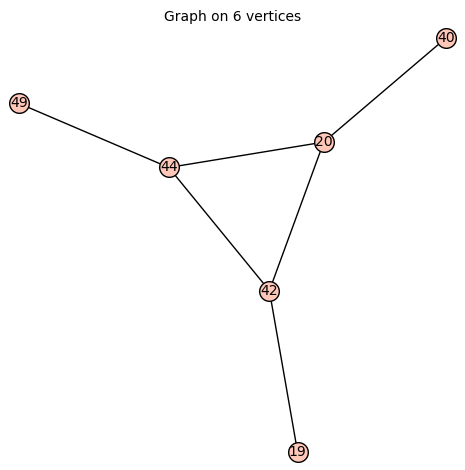

In [11]:
E.isogeny_ell_graph(2, directed=False, label_by_j=True)

Now let's do the same for the 3-isogeny graph. Not all of $E[3]$ is $𝔽_p$-rational. However there is a cyclic group of order 3 inside $E(𝔽_p)$.

In [12]:
E.torsion_basis(3)

ValueError: curve does not have full rational 3-torsion

In [13]:
E(0).division_points(3)

[(0 : 1 : 0), (20 : 21 : 1), (20 : 38 : 1)]

Let's take the Vélu isogeny associated to this rational subgroup, and let's iterate this operation until discovering the whole connected component. We find, again, a cycle.

In [14]:
E1 = E.isogeny(E(0).division_points(3)).codomain()
E1.j_invariant()

42

In [15]:
E2 = E1.isogeny(E1(0).division_points(3)).codomain()
E2.j_invariant()

44

In [16]:
E2.isogeny(E2(0).division_points(3)).codomain().j_invariant()

20

However the three isogenies above are not the only $𝔽_p$-rational isogenies of these 3 curves. We also need to take a look at cyclic subgroups of $E[3]$ that are stabilized by Frobenius, even when their individual points are not stabilized.

For this, we move to an extension field where all the 3-torsion is defined.

In [17]:
KK = K.extension(2)
EE = E.change_ring(KK)
P, Q = EE.torsion_basis(3)
P, Q

((20 : 21 : 1), (27*z2 + 5 : 28*z2 + 12 : 1))

The p-Frobenius isogeny $π:(x,y)↦(x^p,y^p)$ is in fact an endomorphism, because `EE` is secretly defined over $𝔽_p$.

In [18]:
π = EE.frobenius_isogeny()
π

Frobenius endomorphism of degree 59:
  From: Elliptic Curve defined by y^2 = x^3 + 56*x + 53 over Finite Field in z2 of size 59^2
  To:   Elliptic Curve defined by y^2 = x^3 + 56*x + 53 over Finite Field in z2 of size 59^2

Looking at the action of Frobenius on the basis $〈P,Q〉 = E[3]$, we discover that $〈P〉$ is fixed by Frobenius but $〈Q〉$ is not.

In [19]:
π(P)

(20 : 21 : 1)

In [20]:
π(Q)

(32*z2 + 32 : 31*z2 + 40 : 1)

In [21]:
π(Q) == - P - Q

True

We can write this in a matrix, and then we can diagonalize it to find another basis on which $π$ acts like a diagonal matrix. Because this is such a simple example, we do the diagonalization by hand, rather than asking Sage to do it for us.

In [22]:
π.matrix_on_subgroup([P, Q])

[1 0]
[2 2]

In [23]:
R = P - Q
π.matrix_on_subgroup([P,R])

[1 0]
[0 2]

we could have predicted the eigenvalues by looking at the roots of the characteristic polynomial of π modulo 3.

In [24]:
pol = E.frobenius_polynomial().change_ring(GF(3))
pol

x^2 + 2

In [25]:
pol.factor()

(x + 1) * (x + 2)

And finally here's the full $𝔽_p$-rational $3$-isogeny graph, undirected because the isogenies associated to the +1 and -1 eigenvalues of π are dual to one another.

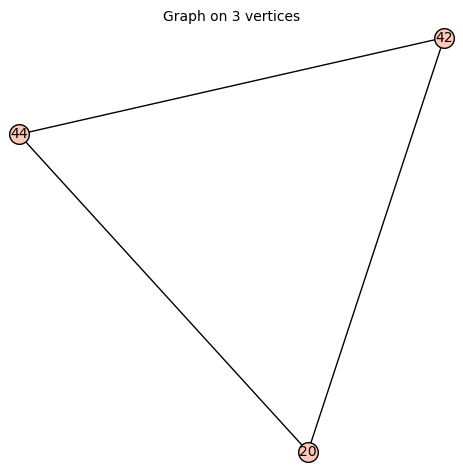

In [26]:
E.isogeny_ell_graph(3, directed=False, label_by_j=True)

Out of curiosity, we can look at the $𝔽_{p^2}$-rational graph. We discover more vertices.

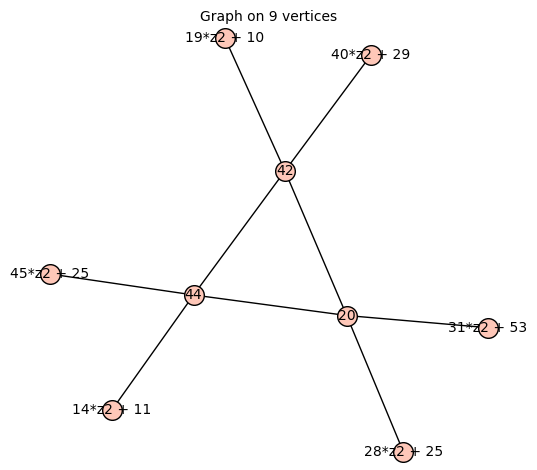

In [27]:
EE.isogeny_ell_graph(3, directed=False, label_by_j=True)

And it never stops! If we keep extending the field (by degree 3 extensions), we find more and more layers in the volcano.

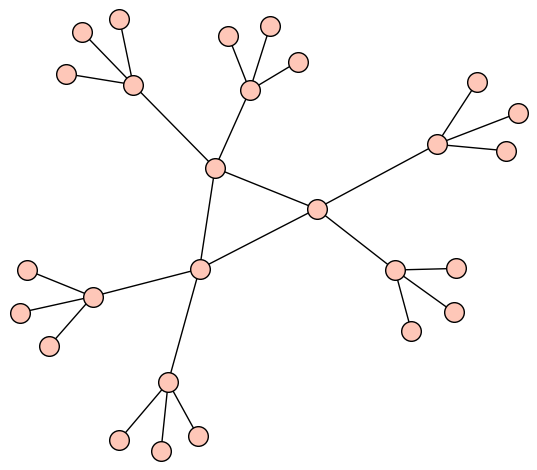

In [29]:
EE.change_ring(KK.extension(3)).isogeny_ell_graph(3, directed=False, label_by_j=True).plot(vertex_labels=False)